<a href="https://colab.research.google.com/github/Mahammad-Haroon/Data-Analysis-Projects/blob/main/K_Means_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Upload the provided dataset
uploaded = files.upload()

# Load the uploaded CSV file
df = pd.read_csv("Customers.csv")

# Update features with correct column names from the DataFrame
features = ["Annual Income ($)", "Spending Score (1-100)"]

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(df.shape)
print(df.head())

Saving Customers.csv to Customers (3).csv
(2000, 8)
   CustomerID  Gender  Age  Annual Income ($)  Spending Score (1-100)  \
0           1    Male   19              15000                      39   
1           2    Male   21              35000                      81   
2           3  Female   20              86000                       6   
3           4  Female   23              59000                      77   
4           5  Female   31              38000                      40   

      Profession  Work Experience  Family Size  
0     Healthcare                1            4  
1       Engineer                3            3  
2       Engineer                1            1  
3         Lawyer                0            2  
4  Entertainment                2            6  


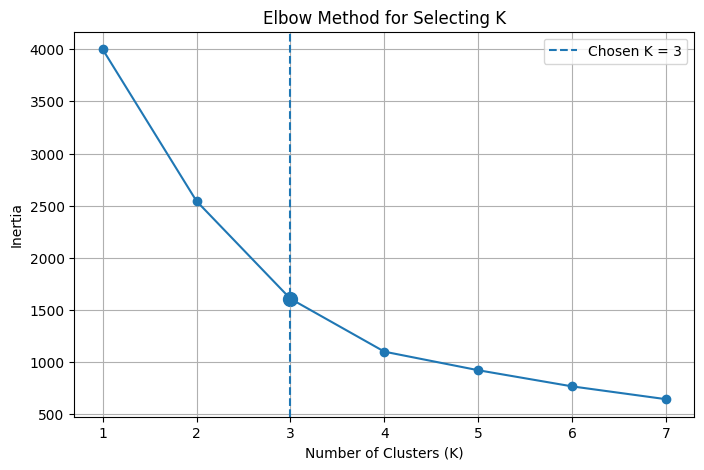

In [8]:
inertias = []

for k in range(1, 8):
    kmeans = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=42
    )

    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 8), inertias, marker="o")

# Mark the chosen K
plt.axvline(3, linestyle="--", label="Chosen K = 3")
plt.scatter(3, inertias[2], s=100)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Selecting K")
plt.xticks(range(1, 8))
plt.legend()
plt.grid(True)

plt.show()

In [9]:
# Selected number of clusters
kmeans = KMeans(
    n_clusters=3,
    n_init=10,
    random_state=42
)

# Train the model
kmeans.fit(X_scaled)

# Attach cluster labels to the dataframe
df["cluster"] = kmeans.labels_

# Display number of customers in each cluster
print("Customer count in each cluster:")
print(df["cluster"].value_counts().sort_index())

Customer count in each cluster:
cluster
0    614
1    725
2    661
Name: count, dtype: int64


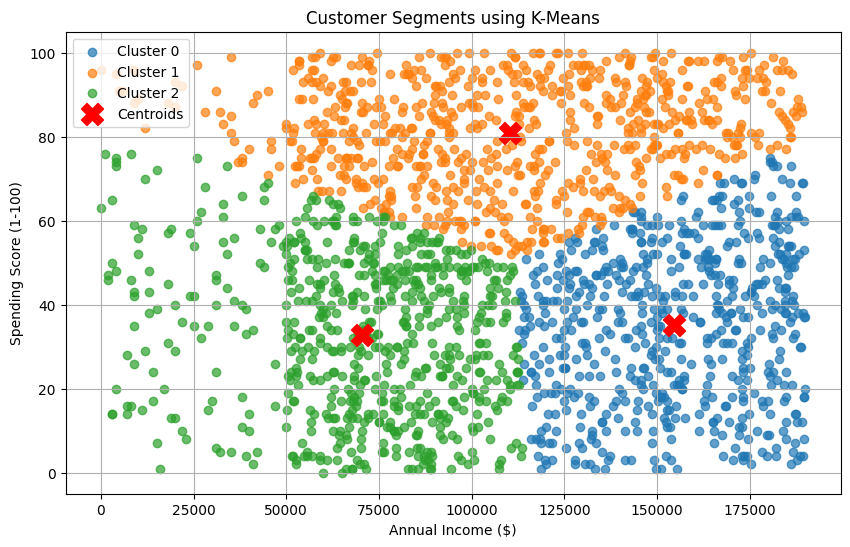

In [11]:
plt.figure(figsize=(10, 6))

# Plot customers by cluster
for cluster in sorted(df["cluster"].unique()):
    cluster_data = df[df["cluster"] == cluster]

    plt.scatter(
        cluster_data["Annual Income ($)"],
        cluster_data["Spending Score (1-100)"],
        label=f"Cluster {cluster}",
        alpha=0.7
    )

# Calculate centroids in original units
centroids = df.groupby("cluster")[features].mean()

# Plot centroids
plt.scatter(
    centroids["Annual Income ($)"],
    centroids["Spending Score (1-100)"],
    marker="X",
    s=250,
    c="red",
    label="Centroids"
)

plt.xlabel("Annual Income ($)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segments using K-Means")
plt.legend()
plt.grid(True)

plt.show()

In [12]:
cluster_profile = df.groupby("cluster")[features].mean()

print("Cluster Profile:")
display(cluster_profile)

Cluster Profile:


,Annual Income ($),Spending Score (1-100)
cluster,,
0,154602.371336,35.086319
1,110367.660690,80.948966
2,70380.080182,32.819970
